<a href="https://colab.research.google.com/github/MR-Goldenyt/Argus/blob/main/Argus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# IT7009 Artificial Intelligence - Selected Project Brief #2

## Intelligent Cyberattack Analysis System


## Phase 1: Data Cleaning and Preprocessing


### i. Imports and Data Loading


In [81]:
# Import Required Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create the figures directory if it doesnt exist
os.makedirs("figures", exist_ok=True)

# Upload this file to the Colab session storage first
DATASET_PATH = "Dataset_Brief_2.csv"

# dirty data frame for future comparisons with clean data
ddf = pd.read_csv(DATASET_PATH, low_memory=False)

# cleaned dataset
df = ddf.copy()

# Display the raw dataset
print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (48826, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,4.835233,1713517.54,16.89,66.33,634.919224,634.919224,0.0,0.0,0.0,0.0,...,23.51914405190254,540.23,8.375931e+07,9.5,32.983477,31.837886,3663.34722,0.14,141.55,Mirai-udpplain
1,0.000000,54.0,6.0,64.00,2.671835,2.671835,0.0,0.0,1.0,0.0,...,0.0,54.0,8.297303e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DoS-SYN_Flood
2,0.000000,54.0,6.0,64.00,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,54.0,8.333120e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-PSHACK_Flood
3,0.000000,0.0,1.0,64.00,160.127665,160.127665,0.0,0.0,0.0,0.0,...,0.0,42.0,8.312889e+07,9.5,9.165151,0.000000,0.00000,0.0,141.55,DDoS-ICMP_Flood
4,0.000000,54.0,6.0,64.00,1.262448,1.262448,0.0,1.0,0.0,1.0,...,0.0,54.0,8.334516e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-RSTFINFlood


### ii. Overall Analysis of Raw Data


In [82]:
# Brief Information
print(df.info())

# Statistical Summary
df.describe(include="all").T.head(20)

<class 'pandas.DataFrame'>
RangeIndex: 48826 entries, 0 to 48825
Data columns (total 47 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   flow_duration    48815 non-null  float64
 1   Header_Length    48815 non-null  str    
 2   Protocol Type    48816 non-null  str    
 3   Duration         48816 non-null  float64
 4   Rate             48814 non-null  float64
 5   Srate            48816 non-null  float64
 6   Drate            48811 non-null  float64
 7   fin_flag_number  48814 non-null  float64
 8   syn_flag_number  48816 non-null  float64
 9   rst_flag_number  48815 non-null  float64
 10  psh_flag_number  48815 non-null  str    
 11  ack_flag_number  48814 non-null  float64
 12  ece_flag_number  48816 non-null  float64
 13  cwr_flag_number  48816 non-null  float64
 14  ack_count        48816 non-null  float64
 15  syn_count        48813 non-null  float64
 16  fin_count        48815 non-null  float64
 17  urg_count        48816 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flow_duration,48815.0,NaN,NaN,NaN,14.495303,382.599894,-999.0,0.0,0.0,0.128624,47629.094561
Header_Length,48815,15623,54.0,14557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Protocol Type,48816,915,6.0,22721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,48816.0,NaN,NaN,NaN,66.276401,12.9069,0.0,64.0,64.0,64.0,255.0
Rate,48814.0,NaN,NaN,NaN,8664.10689,89626.647942,-999.0,2.095422,15.69341,128.325003,3145728.0
Srate,48816.0,NaN,NaN,NaN,8663.824629,89624.823444,-999.0,2.095305,15.69341,128.351765,3145728.0
Drate,48811.0,NaN,NaN,NaN,0.000001,0.000089,0.0,0.0,0.0,0.0,0.014636
fin_flag_number,48814.0,NaN,NaN,NaN,0.083583,0.276764,0.0,0.0,0.0,0.0,1.0
syn_flag_number,48816.0,NaN,NaN,NaN,0.204359,0.403237,0.0,0.0,0.0,0.0,1.0
rst_flag_number,48815.0,NaN,NaN,NaN,0.088559,0.284109,0.0,0.0,0.0,0.0,1.0


### iii. Categorical, Temporal, and Identifier Audit


In [83]:
feature_cols = [c for c in df.columns if c != "label"]
print("Number of feature columns:", len(feature_cols))
print(f"\nColumn dtypes as read:\n{df.dtypes.value_counts()}")
print("\nAny column name suggesting an identifier/date field?")
suspect = [
    c
    for c in df.columns
    if any(k in c.lower() for k in ["id", "date", "time", "timestamp"])
    and c != "flow_duration"
]
print(
    suspect
    if suspect
    else "None found (besides the numeric duration/IAT features, which are not timestamps)."
)
print(
    "\nTarget classes:",
    df["label"].nunique(),
    "| Missing labels:",
    df["label"].isnull().sum(),
)

Number of feature columns: 46

Column dtypes as read:
float64    34
str        13
Name: count, dtype: int64

Any column name suggesting an identifier/date field?
None found (besides the numeric duration/IAT features, which are not timestamps).

Target classes: 33 | Missing labels: 0


### iv. Missing Values and Incorrect Data Types

`df.info()` above shows several columns that should be purely numeric (e.g. `Header_Length`,
`Protocol Type`, etc.) are instead read as `object` type. Inspecting the non-numeric
entries reveals the literal text tokens **`"invalid"`** and **`"unknown"`** planted inside otherwise
numeric cells not a genuine category.

**Proposed Solution:** replace these text tokens with `NaN`, then impute every feature column to numeric dtype.


======== Before ========
Total non-numeric values: 12
Total Missing values: 520
Identfied 2 non-numeric (text) values: ['unknown' 'invalid']
Feature columns with wrong (text) dtype:
01  Header_Length
02  Protocol Type
03  psh_flag_number
04  rst_count
05  HTTPS
06  ICMP
07  IPv
08  LLC
09  Min
10  Std
11  Tot size
12  Variance

======== After ========
Total non-numeric values: 0
Total Missing values: 532
Identfied 0 non-numeric (text) values: []
Feature columns with wrong (text) dtype: (should be empty):

======== Conclusion ========
All 46 feature columns are now numeric typed: True


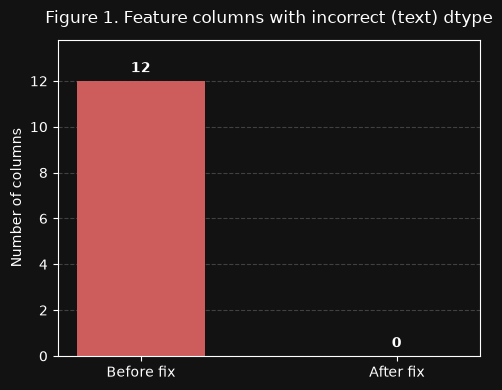

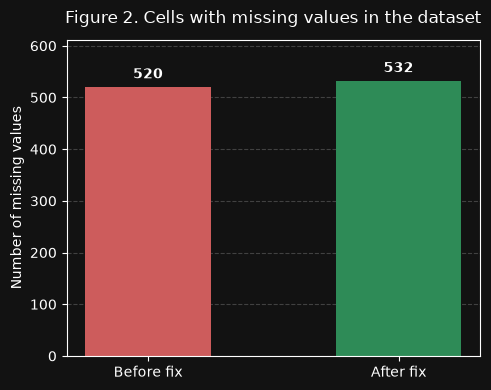

In [84]:
def get_non_numeric_values(data):
    """
    Identifies and returns all non-numeric (text/object) values from a DataFrame.
    Returns a Pandas Series of the raw values (including duplicates).
    """
    # 1. Coerce each column to numeric in one vectorized call per column
    #    (instead of calling pd.to_numeric on every individual cell)
    numeric = data.apply(pd.to_numeric, errors="coerce")

    # 2. A cell is "non-numeric" if it had a real value but failed to coerce
    mask = data.notna() & numeric.isna()

    # 3. Filter and extract the values
    return data.stack()[mask.stack()]

# ======== Before ========
# Features only dataframe
features = df[feature_cols]
# Get both the non-numeric and unique non-numeric values
non_numbers = get_non_numeric_values(features)
unique_non_numbers = non_numbers.unique()
# Get missing values
missing_values_before = df.isna().sum().sum()
# Get all non-numeric cols as a list
object_cols_before = (
    df[feature_cols].select_dtypes(include=["str", "object"]).columns.to_list() # note: use "str" in include to avoid pandas warning
)
print("======== Before ========")
print("Total non-numeric values:", len(non_numbers))
print("Total Missing values:", missing_values_before)
print(f"Identfied {len(unique_non_numbers)} non-numeric (text) values: {unique_non_numbers}")
print("Feature columns with wrong (text) dtype:")
# Format print with padding for readability
# Get digit count for padding
digits = len(str(len(object_cols_before)))
for idx, col in enumerate(object_cols_before, start=1):
    print(f"{idx:0{digits}d}  {col}")

# ======== Cleaning ========
# Clean inconsistent values by replacing and coercing as nan
df[feature_cols] = df[feature_cols].replace(unique_non_numbers, np.nan)
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ======== After ========
# Get both the non-numeric and unique non-numeric values
non_numbers = get_non_numeric_values(df[feature_cols])
unique_non_numbers = non_numbers.unique()
# Get missing values
missing_values_after = df.isna().sum().sum()
object_cols_after = (
    df[feature_cols].select_dtypes(include=["str", "object"]).columns.to_list()
)
print("\n======== After ========")
print("Total non-numeric values:", len(non_numbers))
print("Total Missing values:", missing_values_after)
print(f"Identfied {len(unique_non_numbers)} non-numeric (text) values: {unique_non_numbers}")
print("Feature columns with wrong (text) dtype: (should be empty):")
# Format print with padding for readability
# Get digit count for padding
digits = len(str(len(object_cols_after)))
for idx, col in enumerate(object_cols_after, start=1):
    print(f"{idx:0{digits}d}  {col}")

print("\n======== Conclusion ========")
print("All 46 feature columns are now numeric typed:", len(object_cols_after) == 0)

# ======== Data Comparison ========
# Store values for figure 1 and 2
object_cols = [len(object_cols_before), len(object_cols_after)]
missing_values = [missing_values_before, missing_values_after]
categories = ["Before fix", "After fix"]

# ==== Figure 1 ====
# Initialize figure and axes for figure 1
fig1, ax1 = plt.subplots(figsize=(5, 4))

# Set bar chart attributes
ax1.bar(
    categories,
    object_cols,
    color=["indianred", "seagreen"], 
    width=0.5
)

# use dark background for inverted text color
plt.style.use('dark_background')

# Set background colors (Grey style)
fig1.patch.set_facecolor('#121212') 
ax1.set_facecolor('#121212')

# Set titles and labels for figure 1
ax1.set_title("Figure 1. Feature columns with incorrect (text) dtype", pad=12)
ax1.set_ylabel("Number of columns")

# Add headroom to Y-axis so text labels aren't clipped at the top
max_val = max(object_cols) if object_cols else 1
ax1.set_ylim(0, max_val * 1.15 if max_val > 0 else 1)

# Add text labels above bars
for i, v in enumerate(object_cols):
    ax1.text(i, v + (max_val * 0.02), str(v), ha="center", va="bottom", fontweight="bold", color="white")

# Add subtle horizontal gridlines for readability
ax1.grid(True, axis='y', linestyle='--', alpha=0.2)
ax1.set_axisbelow(True)

plt.tight_layout()

# Saving fig1 bar chart to file
plt.savefig("figures/fig1_dtype_fix.png", dpi=240)

# ==== Figure 2 ====
# Initialize figure and axes for figure 2
fig2, ax2 = plt.subplots(figsize=(5, 4))

# Set bar chart attributes
ax2.bar(
    categories,
    missing_values,
    color=["indianred", "seagreen"],
    width=0.5
)

# use dark background for inverted text color
plt.style.use('dark_background')

# Set background colors (Grey style)
fig2.patch.set_facecolor('#121212') 
ax2.set_facecolor('#121212')

# Set titles and labels for figure 2
ax2.set_title("Figure 2. Cells with missing values in the dataset", pad=12)
ax2.set_ylabel("Number of missing values")

# Add headroom to Y-axis so text labels aren't clipped at the top
max_val = max(missing_values) if missing_values else 1
ax2.set_ylim(0, max_val * 1.15 if max_val > 0 else 1)

# Add text labels above bars
for i, v in enumerate(missing_values):
    ax2.text(i, v + (max_val * 0.02), str(v), ha="center", va="bottom", fontweight="bold", color="white")

# Add subtle horizontal gridlines for readability
ax2.grid(True, axis='y', linestyle='--', alpha=0.2)
ax2.set_axisbelow(True)

plt.tight_layout()

# Saving fig2 bar chart to file
plt.savefig("figures/fig2_missing_values.png", dpi=240)



### Detecting and Fixing Outliers using Interquartile Range (IQR)